In [106]:
# Cell 1 — project path setup

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [107]:
# Cell 2 — imports

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

from src.loaders import load_function
from src.utils import get_best_point, get_top_points, format_query

In [108]:
# Cell 3 — choose the week

week_num = 14
data_root = Path(rf"D:\Capstone_BBO\data\week_{week_num}")

print(rf"Working on Week {week_num}")
print("Data folder:", data_root.resolve())

Working on Week 14
Data folder: D:\Capstone_BBO\data\week_14


In [109]:
# Cell 4 — load all 8 functions automatically

functions_data = {}

for fn in range(1, 9):
    function_folder = data_root / f"function_{fn}"
    inputs_path = function_folder / "initial_inputs.npy"
    outputs_path = function_folder / "initial_outputs.npy"

    X, y = load_function(inputs_path, outputs_path)

    functions_data[fn] = {
        "folder": function_folder,
        "inputs_path": inputs_path,
        "outputs_path": outputs_path,
        "X": X,
        "y": y
    }

print("Loaded functions:", list(functions_data.keys()))

Loaded functions: [1, 2, 3, 4, 5, 6, 7, 8]


In [110]:
# Cell 5 — quick overview of all functions

overview_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    overview_rows.append({
        "function": fn,
        "n_points": X.shape[0],
        "dimension": X.shape[1],
        "y_min": float(np.min(y)),
        "y_max": float(np.max(y)),
        "y_mean": float(np.mean(y)),
        "y_std": float(np.std(y))
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,function,n_points,dimension,y_min,y_max,y_mean,y_std
0,1,12,2,-0.003606,7.710875e-16,-0.000301,0.000997
1,2,12,2,-0.065624,6.655822e-01,0.301561,0.259739
2,3,17,3,-0.398926,-3.483531e-02,-0.099480,0.081862
3,4,32,4,-32.625660,-3.828713e+00,-16.406622,7.520437
4,5,22,4,0.112940,1.144653e+03,239.043119,363.226815
5,6,22,5,-2.571170,-7.063869e-01,-1.426441,0.480518
6,7,32,6,0.002701,1.402672e+00,0.292370,0.406223
7,8,42,8,5.592193,9.598482e+00,7.900123,0.998958


In [111]:
# Cell 6 — best point for each function

best_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    best_rows.append({
        "function": fn,
        "best_index": int(best_idx),
        "best_output": float(best_y),
        "best_point": best_x,
        "formatted_best_point": format_query(best_x)
    })

best_df = pd.DataFrame(best_rows)
best_df

,function,best_index,best_output,best_point,formatted_best_point
0,1,2,7.710875e-16,"[0.7310236309563586, 0.7329998764152272]",0.731024-0.733000
1,2,11,6.655822e-01,"[0.702637, 0.940484]",0.702637-0.940484
2,3,3,-3.483531e-02,"[0.49258141463713434, 0.6115931882759961, 0.34...",0.492581-0.611593-0.340176
3,4,31,-3.828713e+00,"[0.567788, 0.426327, 0.425826, 0.249007]",0.567788-0.426327-0.425826-0.249007
4,5,21,1.144653e+03,"[0.197574, 0.8598, 0.879484, 0.878516]",0.197574-0.859800-0.879484-0.878516
5,6,20,-7.063869e-01,"[0.728186, 0.154693, 0.732552, 0.693997, 0.056...",0.728186-0.154693-0.732552-0.693997-0.056401
6,7,31,1.402672e+00,"[0.057896, 0.487666, 0.247422, 0.218118, 0.420...",0.057896-0.487666-0.247422-0.218118-0.420428-0...
7,8,40,9.598482e+00,"[0.056447, 0.065956, 0.022929, 0.038786, 0.403...",0.056447-0.065956-0.022929-0.038786-0.403935-0...


In [112]:
# Cell 7 — top 5 points for a chosen function

# This lets you inspect one function in detail without changing paths.
inspect_function = 3

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

top_idx, top_X, top_y = get_top_points(X, y, top_n=5)

col_names = [f"x{i+1}" for i in range(X.shape[1])]
top_df = pd.DataFrame(top_X, columns=col_names)
top_df["y"] = top_y
top_df["original_index"] = top_idx

print(f"Top 5 points for Function {inspect_function}")
top_df

Top 5 points for Function 3


,x1,x2,x3,y,original_index
0,0.492581,0.611593,0.340176,-0.034835,3
1,0.600097,0.725136,0.066089,-0.036378,13
2,0.492581,0.590954,0.340176,-0.039700,16
3,0.492581,0.611593,0.340176,-0.043951,15
4,0.220549,0.297825,0.343555,-0.046947,10


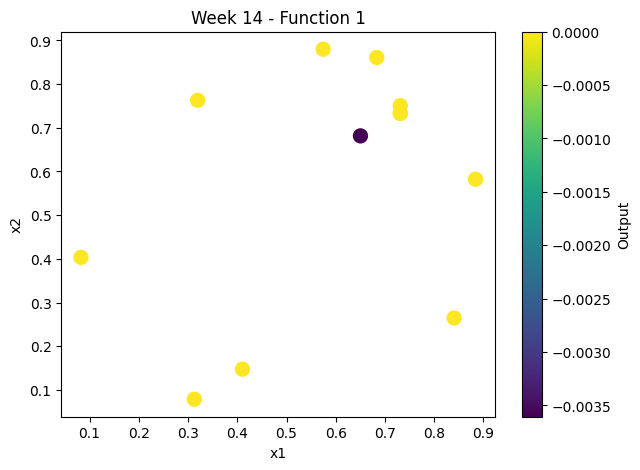

In [113]:
#Cell 9 — create initial candidate table

# This gives you a starting point for all 8 functions.

# For now, the initial candidate is just the current best point. Later we will improve this.

inspect_function = 1

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

if X.shape[1] == 2:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=100)
    plt.colorbar(sc, label="Output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Week {week_num} - Function {inspect_function}")
    plt.show()
else:
    print(f"Function {inspect_function} is {X.shape[1]}D, so no simple 2D scatter plot.")

In [114]:
manual_candidates = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None
}

In [115]:
def generate_gp_candidate(X, y, n_random=3000, beta=2.0, random_state=42):
    """
    Fit a Gaussian Process and choose a candidate using
    an Upper Confidence Bound (UCB) acquisition rule.

    score = mean + beta * std
    """
    rng = np.random.default_rng(random_state)
    dim = X.shape[1]

    # Candidate search points sampled in [0, 1]^dim
    X_search = rng.uniform(0, 1, size=(n_random, dim))

    # GP model
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state
    )

    gp.fit(X, y)
    mu, std = gp.predict(X_search, return_std=True)

    ucb = mu + beta * std
    order = np.argsort(ucb)[::-1]

    for idx in order:
        candidate = X_search[idx]
        already_exists = np.any(np.all(np.isclose(X, candidate, atol=1e-6), axis=1))
        if not already_exists:
            return candidate, gp, X_search, mu, std, ucb

    return X_search[order[0]], gp, X_search, mu, std, ucb

In [116]:
np.random.seed(42)

auto_candidates = {}
candidate_method = {}

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]
    dim = X.shape[1]

    # Use GP-based BO for lower-dimensional functions
    if dim <= 4:
        candidate, gp_model, X_search, mu, std, ucb = generate_gp_candidate(
            X, y, n_random=3000, beta=2.0, random_state=42 + fn
        )
        auto_candidates[fn] = candidate
        candidate_method[fn] = "GP_UCB"

    # Keep local heuristic for higher-dimensional functions
    else:
        top_idx, top_X, top_y = get_top_points(X, y, top_n=min(3, len(y)))
        anchor = top_X[0].copy()

        step = 0.02
        n_change = 2

        candidate = anchor.copy()

        for _ in range(100):
            test_candidate = anchor.copy()
            change_idx = np.random.choice(dim, size=n_change, replace=False)
            noise = np.random.uniform(-step, step, size=n_change)

            test_candidate[change_idx] = test_candidate[change_idx] + noise
            test_candidate = np.clip(test_candidate, 0, 1)

            already_exists = np.any(np.all(np.isclose(X, test_candidate, atol=1e-12), axis=1))
            if not already_exists:
                candidate = test_candidate
                break

        auto_candidates[fn] = candidate
        candidate_method[fn] = "Local_Search"

auto_candidates

d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarnin

{1: array([0.70552461, 0.88539276]),
 2: array([0.98519632, 0.534335  ]),
 3: array([0.97472271, 0.68198643, 0.85023365]),
 4: array([0.46800256, 0.38341381, 0.26635552, 0.3760725 ]),
 5: array([0.80009952, 0.52259554, 0.99382642, 0.99982925]),
 6: array([0.728186  , 0.16588064, 0.732552  , 0.693997  , 0.06027501]),
 7: array([0.0619406 , 0.487666  , 0.247422  , 0.218118  , 0.420428  ,
        0.72748405]),
 8: array([0.03647815, 0.065956  , 0.022929  , 0.038786  , 0.403935  ,
        0.801055  , 0.50799546, 0.893085  ])}

In [117]:
submission_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    chosen_candidate = manual_candidates.get(fn)
    if chosen_candidate is None:
        chosen_candidate = auto_candidates[fn]

    chosen_candidate = np.array(chosen_candidate, dtype=float)
    chosen_candidate = np.clip(chosen_candidate, 0, 1)

    already_exists = np.any(np.all(np.isclose(X, chosen_candidate, atol=1e-12), axis=1))

    submission_rows.append({
        "function": fn,
        "dimension": X.shape[1],
        "method": candidate_method.get(fn, "Manual"),
        "best_output_so_far": float(best_y),
        "best_point_so_far": format_query(best_x),
        "chosen_candidate_array": chosen_candidate,
        "query": format_query(chosen_candidate),
        "already_exists": bool(already_exists)
    })

submission_df = pd.DataFrame(submission_rows)
submission_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists
0,1,2,GP_UCB,7.710875e-16,0.731024-0.733000,"[0.7055246061909509, 0.8853927559533575]",0.705525-0.885393,False
1,2,2,GP_UCB,6.655822e-01,0.702637-0.940484,"[0.9851963228318182, 0.534335003186848]",0.985196-0.534335,False
2,3,3,GP_UCB,-3.483531e-02,0.492581-0.611593-0.340176,"[0.9747227143159516, 0.681986434149603, 0.8502...",0.974723-0.681986-0.850234,False
3,4,4,GP_UCB,-3.828713e+00,0.567788-0.426327-0.425826-0.249007,"[0.4680025640904303, 0.3834138055531585, 0.266...",0.468003-0.383414-0.266356-0.376073,False
4,5,4,GP_UCB,1.144653e+03,0.197574-0.859800-0.879484-0.878516,"[0.8000995246278992, 0.5225955442106849, 0.993...",0.800100-0.522596-0.993826-0.999829,False
5,6,5,Local_Search,-7.063869e-01,0.728186-0.154693-0.732552-0.693997-0.056401,"[0.728186, 0.16588064001091077, 0.732552, 0.69...",0.728186-0.165881-0.732552-0.693997-0.060275,False
6,7,6,Local_Search,1.402672e+00,0.057896-0.487666-0.247422-0.218118-0.420428-0...,"[0.06194060046972835, 0.487666, 0.247422, 0.21...",0.061941-0.487666-0.247422-0.218118-0.420428-0...,False
7,8,8,Local_Search,9.598482e+00,0.056447-0.065956-0.022929-0.038786-0.403935-0...,"[0.03647815063364057, 0.065956, 0.022929, 0.03...",0.036478-0.065956-0.022929-0.038786-0.403935-0...,False


In [118]:
repeated_df = submission_df[submission_df["already_exists"] == True]
repeated_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists


In [119]:
submission_export = submission_df[["function", "query"]].copy()

output_file = Path(rf"D:\Capstone_BBO\submissiones\week_{week_num}_submission.csv")
submission_export.to_csv(output_file, index=False)

print("Saved submission file to:", output_file.resolve())
submission_export

Saved submission file to: D:\Capstone_BBO\submissiones\week_14_submission.csv


,function,query
0,1,0.705525-0.885393
1,2,0.985196-0.534335
2,3,0.974723-0.681986-0.850234
3,4,0.468003-0.383414-0.266356-0.376073
4,5,0.800100-0.522596-0.993826-0.999829
5,6,0.728186-0.165881-0.732552-0.693997-0.060275
6,7,0.061941-0.487666-0.247422-0.218118-0.420428-0...
7,8,0.036478-0.065956-0.022929-0.038786-0.403935-0...
